In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install -q roboflow ultralytics lapx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.7 MB/s eta 0:00:00


In [ ]:
import os

# configuration
BASE_DIR = "/content/drive/MyDrive/YOLO_trained_models"
PROJECT_NAME = "yolo_car_18_640_150epochs"

ROBOLFOW_API_KEY = "YOUR_API"

os.makedirs(BASE_DIR, exist_ok=True)

In [4]:
from roboflow import Roboflow

# downloading roboflow dataset
rf = Roboflow(api_key = ROBOLFOW_API_KEY)
project = rf.workspace("archie-junio-dxv5t").project("car-detection-model-bwjpb")
version = project.version(18)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Detection-Model-18 in yolo26:: 100%|██████████| 6766/6766 [00:00<00:00, 7490.46it/s]


In [4]:
from ultralytics import YOLO

# model training
model = YOLO("yolo26n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=150,
    imgsz=640,
    batch=-1,
    patience=20,
    project = BASE_DIR,
    name = PROJECT_NAME,
    save=True,
    save_period=15
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Detection-Model-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea0357dbcb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046, 

In [ ]:
# display results, for more search in /PROJECT_NAME folder
from IPython.display import Image
Image(filename=f'{BASE_DIR}/{PROJECT_NAME}/results.png', width=800)
Image(filename=f'{BASE_DIR}/{PROJECT_NAME}/val_batch0_pred.jpg', width=1000)

In [13]:
import cv2
from ultralytics import YOLO

# tracking from custom model
custom_model = YOLO(f"{BASE_DIR}/{PROJECT_NAME}/weights/best.pt")
video_path = "traffic.mp4"
output_path = "test_video_18.mp4"

cap = cv2.VideoCapture(video_path)

w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # tracking
    results = custom_model.track(frame, imgsz=2560, persist=True, conf=0.1, tracker="bytetrack.yaml")

    annotated_frame = results[0].plot()
    out.write(annotated_frame)

cap.release()
out.release()
print(f"Video saved: {output_path}")


0: 1440x2560 2 Pickups, 5 SUVs, 17 Sedans, 49.9ms
Speed: 23.3ms preprocess, 49.9ms inference, 0.4ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 4 SUVs, 14 Sedans, 42.7ms
Speed: 24.7ms preprocess, 42.7ms inference, 0.5ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 3 SUVs, 11 Sedans, 37.7ms
Speed: 25.6ms preprocess, 37.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 3 SUVs, 9 Sedans, 37.7ms
Speed: 25.2ms preprocess, 37.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 5 SUVs, 10 Sedans, 34.0ms
Speed: 24.0ms preprocess, 34.0ms inference, 0.4ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 5 SUVs, 12 Sedans, 34.0ms
Speed: 22.2ms preprocess, 34.0ms inference, 0.4ms postprocess per image at shape (1, 3, 1440, 2560)

0: 1440x2560 1 Pickup, 5 SUVs, 13 Sedans, 34.0ms
Speed: 25.0ms preprocess, 34.0ms inference, 0.5ms 

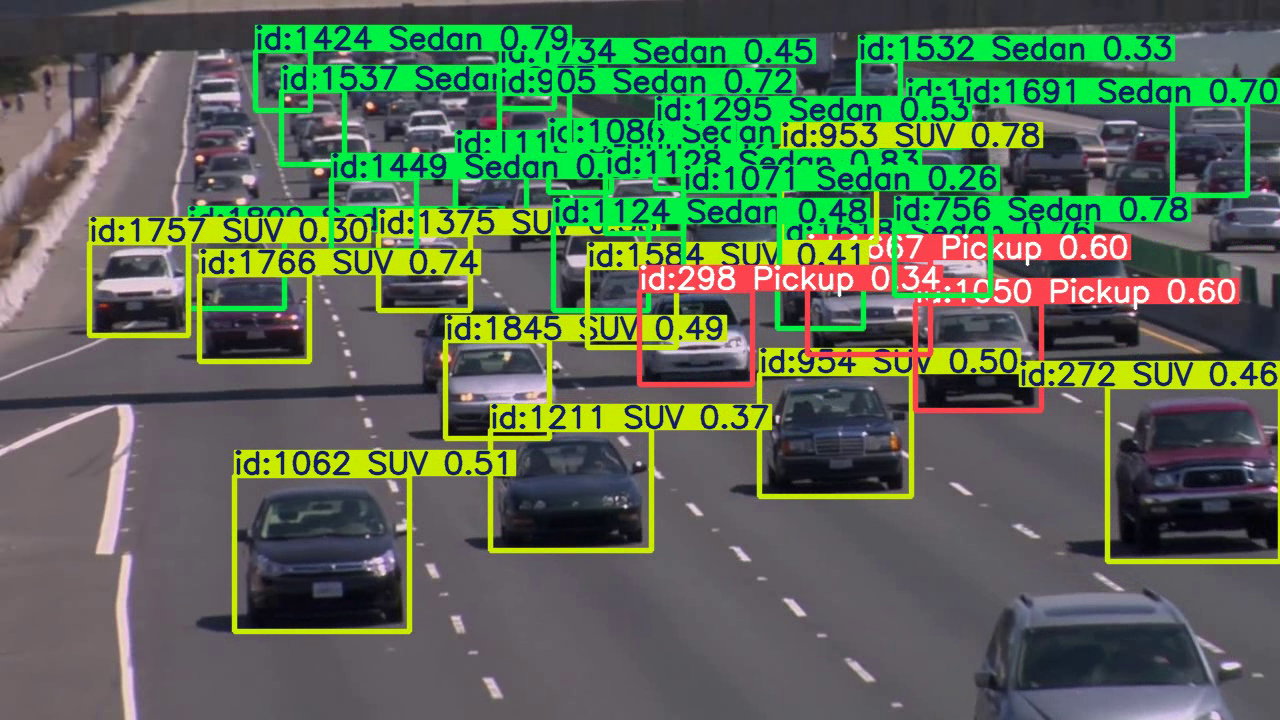

In [20]:
from PIL import Image

# one frame display
target_frame_index = 460

cap_check = cv2.VideoCapture(output_path)
cap_check.set(cv2.CAP_PROP_POS_FRAMES, target_frame_index)
ret, frame = cap_check.read()
cap_check.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(frame_rgb)
    display(img)
else:
    print(f"Error: Frame {target_frame_index} not found.")